#Project: Flipkart Reviews Sentiment Analysis using Python

#1. Importing Necessary Libraries and Dataset:

# • Load required Python libraries:

In [1]:
# Import required Python libraries

import pandas as pd      # (Used to load and handle the dataset)
import numpy as np       # (Used for numerical operations)

import matplotlib.pyplot as plt   # (Used for data visualization)
import seaborn as sns             # (Used for advanced visualization)

import re                # (Used for text cleaning)

from sklearn.model_selection import train_test_split   # (Used to split data into training and testing)

from sklearn.feature_extraction.text import TfidfVectorizer   # (Used to convert text data into numerical features)

from sklearn.naive_bayes import MultinomialNB          # (Machine learning model for text classification)

from sklearn.metrics import accuracy_score, classification_report   # (Used to evaluate model performance)

**Pandas** for handling datasets.

In [2]:
from google.colab import files
uploaded=files.upload()

Saving flipkart_data.csv to flipkart_data.csv


In [3]:
flipkart_data=pd.read_csv("flipkart_data.csv")

In [4]:
flipkart_data.columns

Index(['review', 'rating'], dtype='object')

In [11]:
# Display first 5 rows
flipkart_data.head()   # Shows the first few records of the dataset

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


In [12]:
# Check dataset structure
flipkart_data.info()   # Displays column names, data types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  9976 non-null   object
 1   rating  9976 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 156.0+ KB


Scikit-learn for machine learning algorithms and vectorization.

In [5]:
from sklearn.model_selection import train_test_split      # Used to split dataset into training and testing
from sklearn.feature_extraction.text import TfidfVectorizer  # Used to convert text into numerical features
from sklearn.naive_bayes import MultinomialNB             # Machine learning algorithm for text classification

Matplotlib/Seaborn for data visualization.

In [6]:
import matplotlib.pyplot as plt   # Matplotlib (used for creating basic graphs)
import seaborn as sns             # Seaborn (used for advanced data visualizations)

WordCloud for visualizing common words in reviews.


In [8]:
from wordcloud import WordCloud   # WordCloud (used to visualize the most frequent words in reviews)

Warnings to suppress unnecessary messages.

In [9]:
import warnings
warnings.filterwarnings("ignore")   # Used to suppress unnecessary warning messages

#2. Data Preprocessing:

• Remove missing values and duplicate entries.

In [14]:
# Remove missing values
flipkart_data = flipkart_data.dropna()

# Remove duplicate rows
flipkart_data = flipkart_data.drop_duplicates()

• Convert text into lowercase and remove stopwords, punctuation, and special characters.

In [16]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Function to clean text
def clean_text(text):
    text = text.lower()   # Convert text to lowercase
    text = re.sub(r'[^\w\s]', '', text)   # Remove punctuation and special characters
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]  # Remove stopwords
    return " ".join(words)

# Apply cleaning to review column
flipkart_data['clean_review'] = flipkart_data['review'].apply(clean_text)

Explanation:- This step converts review text to lowercase and removes stopwords, punctuation, and special characters to prepare the text for machine learning.

• Tokenize text data using TF-IDF (Term Frequency-Inverse Document
Frequency).

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text data into numerical features using TF-IDF
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(flipkart_data['clean_review'])

• Encode sentiment labels (Positive = 1, Negative = 0).

In [21]:
# Encode sentiment labels
flipkart_data['Sentiment'] = flipkart_data['rating'].apply(lambda x: 1 if x > 3 else 0)

• Split dataset into training (80%) and testing (20%) sets.

In [22]:
from sklearn.model_selection import train_test_split

# Target variable (Sentiment)
y = flipkart_data['Sentiment']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3. Exploratory Data Analysis (EDA):
• Visualize sentiment distribution using count plots.

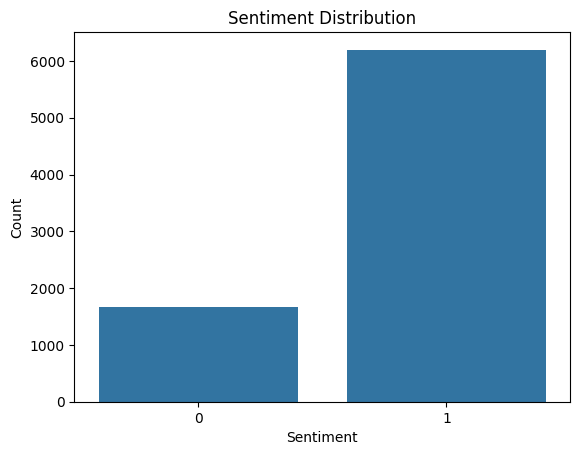

In [23]:
# Visualize sentiment distribution
sns.countplot(x='Sentiment', data=flipkart_data)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Explanation:- This count plot shows how many positive and negative reviews are present in the dataset.

• Create a word cloud to identify common words in positive and negative
reviews.

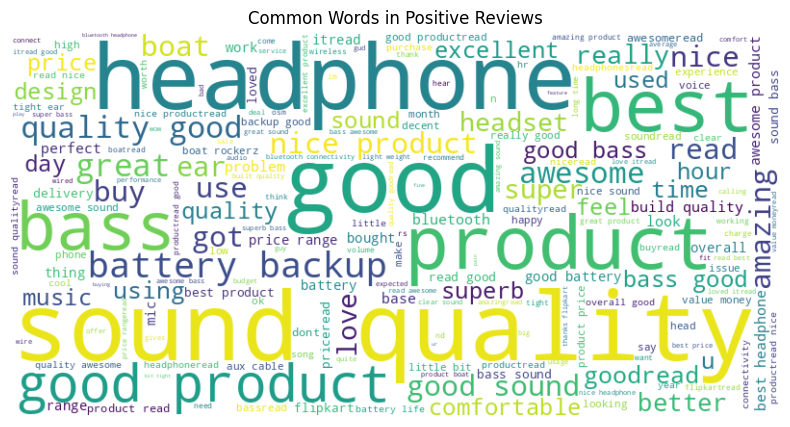

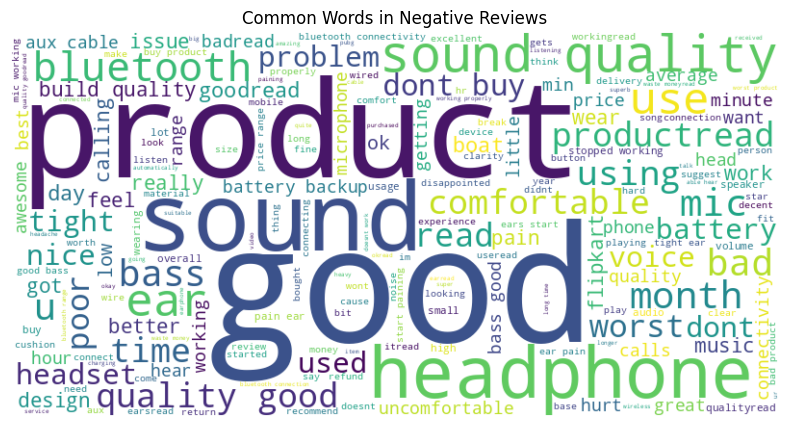

In [24]:
# WordCloud for Positive reviews
positive_words = " ".join(flipkart_data[flipkart_data['Sentiment'] == 1]['clean_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Words in Positive Reviews")
plt.show()


# WordCloud for Negative reviews
negative_words = " ".join(flipkart_data[flipkart_data['Sentiment'] == 0]['clean_review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Words in Negative Reviews")
plt.show()

Explanation:- This creates word clouds to visualize the most common words in positive and negative reviews.

• Analyze correlations between review length and sentiment.

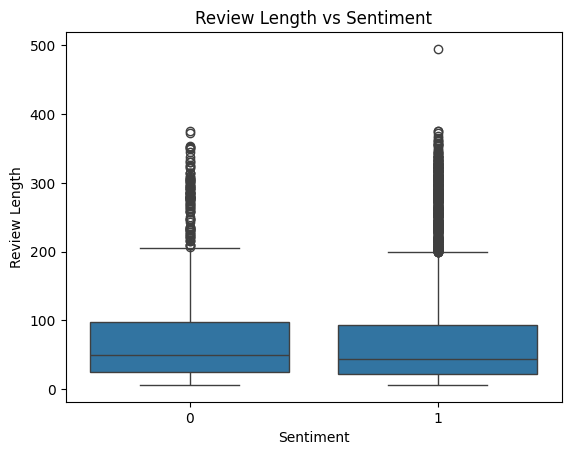

In [25]:
# Create review length feature
flipkart_data['review_length'] = flipkart_data['clean_review'].apply(len)

# Analyze correlation between review length and sentiment
sns.boxplot(x='Sentiment', y='review_length', data=flipkart_data)

plt.title("Review Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")
plt.show()

Explanation:- This visualization shows how review length varies between positive and negative sentiments.

#4. Model Training and Selection:

• Train different machine learning models:

Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Train model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8564167725540025
Logistic Regression F1 Score: 0.9154824233358265


Explanation:
Logistic Regression is used to classify reviews as positive or negative based on learned patterns.

Naïve Bayes

In [28]:
from sklearn.naive_bayes import MultinomialNB

# Train model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Prediction
nb_pred = nb_model.predict(X_test)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("Naive Bayes F1 Score:", f1_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8081321473951716
Naive Bayes F1 Score: 0.8920657612580415


Explanation:
Naïve Bayes is commonly used for text classification and works well with TF-IDF features.

Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))

Random Forest Accuracy: 0.8589580686149937
Random Forest F1 Score: 0.9164785553047404


Explanation:
Random Forest uses multiple decision trees to improve prediction accuracy.

Support Vector Machine (SVM)

In [30]:
from sklearn.svm import SVC

# Train model
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Prediction
svm_pred = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM F1 Score:", f1_score(y_test, svm_pred))

SVM Accuracy: 0.8627700127064803
SVM F1 Score: 0.918979744936234


Explanation:
SVM finds the best boundary that separates positive and negative reviews.

#5. Model Evaluation and Prediction:

Accuracy Score

In [31]:
from sklearn.metrics import accuracy_score

# Calculate Accuracy
accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8564167725540025


Precision, Recall, F1-Score

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision, Recall, and F1-Score for Logistic Regression
precision = precision_score(y_test, lr_pred)
recall = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.8613652357494722
Recall: 0.9768555466879489
F1-Score: 0.9154824233358265


Confusion Matrix

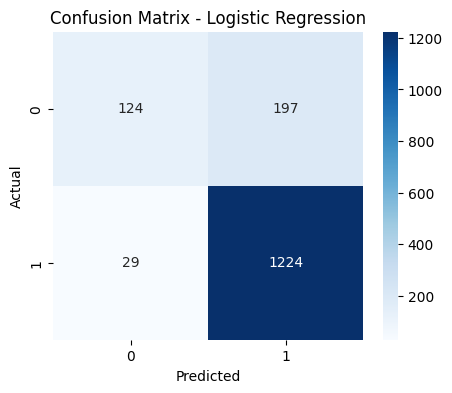

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_pred)

# Visualize using heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

• Test the model on new reviews to classify sentiment as positive or negative.

In [34]:
# Example new reviews
new_reviews = [
    "The product quality is amazing and delivery was fast!",
    "Very poor packaging, totally disappointed."
]

# Clean the new reviews (same preprocessing as training data)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

cleaned_reviews = [clean_text(review) for review in new_reviews]

# Convert to TF-IDF features
new_X = tfidf.transform(cleaned_reviews)

# Predict sentiment using trained Logistic Regression model
predictions = lr_model.predict(new_X)

# Map numerical labels back to text
sentiment_map = {1: "Positive", 0: "Negative"}
predicted_sentiments = [sentiment_map[pred] for pred in predictions]

# Display results
for review, sentiment in zip(new_reviews, predicted_sentiments):
    print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")

Review: The product quality is amazing and delivery was fast!
Predicted Sentiment: Positive

Review: Very poor packaging, totally disappointed.
Predicted Sentiment: Negative



Explanation:- This code classifies new Flipkart reviews as positive or negative using the trained machine learning model.

#Conclusion:

This project demonstrates how machine learning models can automatically classify Flipkart product reviews as positive or negative, helping businesses understand customer feedback and improve product quality. For future improvements, advanced deep learning models like LSTM or Transformer networks could be used to capture more complex patterns in text and improve sentiment prediction accuracy.